# 02: Set up task 1

A task is a fixed ten-class classification problem. We will load its class assignment, select training and validation images, and inspect the local labels and batches.

Task IDs are zero-based, matching our experiment definition: **task ID 1 is the second group**, after task 0. We prepare the data here; model training is a later step.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if not (HERE / "tasks.py").is_file():
    HERE = HERE / "hypernetwork" / "uncle_from_scratch"
if not (HERE / "tasks.py").is_file():
    raise RuntimeError("Launch from the repository root or uncle_from_scratch")
sys.path.insert(0, str(HERE.resolve()))

import matplotlib.pyplot as plt
import torch
from tasks import load_partition, build_task
from task1 import describe_task, show_task

TASK_ID = 1
SEED = 42

## 1. Fix the class partition

Sort the 200 WordNet IDs, shuffle with seed 42 using NumPy PCG64, then divide into 20 groups of ten. Save the assignment so future learn, forget, and relearn requests refer to the same classes. This is our experiment choice, not a claim about the original paper's partition.

In [2]:
partition = load_partition(seed=SEED)
groups = partition["tasks"]
all_classes = [wnid for group in groups for wnid in group["wnids"]]
assert len(groups) == 20
assert len(all_classes) == len(set(all_classes)) == 200
assert all(len(group["wnids"]) == 10 for group in groups)
print("Task ID:", TASK_ID)
print("WordNet IDs in local-label order:", groups[TASK_ID]["wnids"])

Task ID: 1
WordNet IDs in local-label order: ['n02002724', 'n07583066', 'n03424325', 'n02085620', 'n04133789', 'n09332890', 'n07871810', 'n02190166', 'n04023962', 'n02410509']


## 2. Select images and remap labels

A global label identifies one of 200 classes. A local label identifies one of this task's ten classes. For each image, the wrapper finds its global label and returns the corresponding local label. Validation must use exactly the same mapping.

In [3]:
train, val, train_loader, val_loader = build_task(task_id=TASK_ID, seed=SEED)
report = describe_task(train, val)
print(f"Training: {len(train):,} images; validation: {len(val):,} images")
print("local | global | WordNet ID | train | val | name")
for row in report["classes"]:
    print(f"{row['local_label']:5} | {row['global_label']:6} | {row['wnid']} | {row['train_images']:5} | {row['val_images']:3} | {row['name']}")
assert len(train) == 5000 and len(val) == 500
assert train.class_to_idx == val.class_to_idx
assert set(train.targets) == set(val.targets) == set(range(10))
assert all(row["train_images"] == 500 and row["val_images"] == 50 for row in report["classes"])
assert {train.base.image_path(i) for i in train.indices}.isdisjoint(
    {val.base.image_path(i) for i in val.indices}
)

Training: 5,000 images; validation: 500 images
local | global | WordNet ID | train | val | name
    0 |     20 | n02002724 |   500 |  50 | black stork, Ciconia nigra
    1 |    178 | n07583066 |   500 |  50 | guacamole
    2 |    106 | n03424325 |   500 |  50 | gasmask, respirator, gas helmet
    3 |     24 | n02085620 |   500 |  50 | Chihuahua
    4 |    144 | n04133789 |   500 |  50 | sandal
    5 |    197 | n09332890 |   500 |  50 | lakeside, lakeshore
    6 |    190 | n07871810 |   500 |  50 | meat loaf, meatloaf
    7 |     37 | n02190166 |   500 |  50 | fly
    8 |    138 | n04023962 |   500 |  50 | punching bag, punch bag, punching ball, punchball
    9 |     50 | n02410509 |   500 |  50 | bison


## 3. See each class

Each panel shows a training image with its local label. These labels are meaningful only with the task ID and saved mapping.

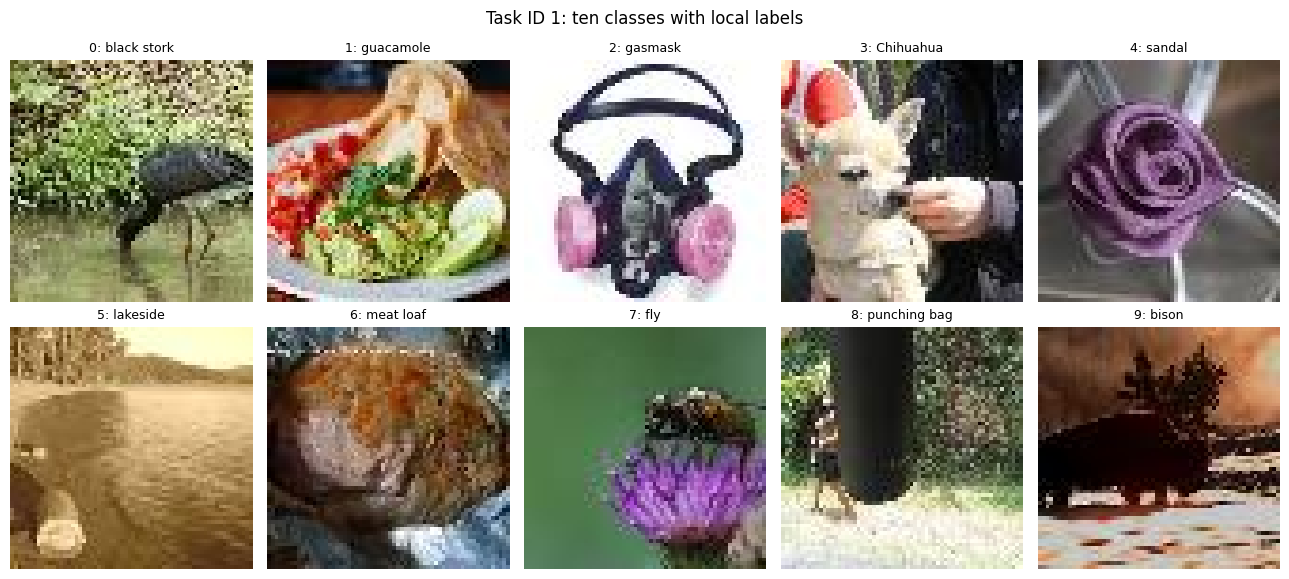

In [4]:
fig = show_task(train, seed=SEED)
plt.show()

## 4. Check batches for the future classifier

The input shape is `(batch, 3, 64, 64)` and the target shape is `(batch,)`. A classifier for this task will produce ten scores per image. Training shuffles, validation does not, and neither loader drops its final partial batch. Pixels are scaled to [0, 1] without augmentation or normalization.

In [5]:
for split, loader in [("train", train_loader), ("val", val_loader)]:
    images, labels = next(iter(loader))
    print(split, "images:", tuple(images.shape), images.dtype,
          "labels:", tuple(labels.shape), labels.dtype)
    print("Label sample:", labels[:16].tolist())
    assert images.shape == (32, 3, 64, 64)
    assert labels.dtype == torch.int64
    assert 0 <= labels.min() and labels.max() < 10
    assert 0 <= images.min() and images.max() <= 1

train images: (32, 3, 64, 64) torch.float32 labels: (32,) torch.int64
Label sample: [9, 6, 4, 8, 2, 8, 0, 9, 0, 4, 2, 8, 4, 1, 1, 5]
val images: (32, 3, 64, 64) torch.float32 labels: (32,) torch.int64
Label sample: [0, 8, 7, 9, 6, 3, 2, 4, 3, 8, 7, 6, 9, 0, 2, 6]


Task 1 is ready for a ten-output classifier. The saved partition defines which classes it contains; the request sequence will define when to learn or forget it. A task-aware experiment supplies the task ID at evaluation time.

Run `python task1.py` from this folder to save the class report and example grid under `outputs/task1/`.